In [1]:
import os
import time
import platform
from shutil import rmtree
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as image
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':  # Mac OS
    plt.rc('font', family='AppleGothic')
else:  # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 오류 발생시
sklearn.set_config(display="text")

# Intel Image Classification 분류 데이터셋
- Intel Image Classification 데이터셋은 인텔(Intel)이 호스팅한 해커톤/컴퓨터 비전 경진대회용 데이터셋으로,  
  자연 풍경 및 도시 공간 이미지로 구성된 6개 클래스 분류 데이터셋입니다.

[Intel Image Classification 링크](https://www.kaggle.com/datasets/puneet6060/intel-image-classification)

### Intel Image Classification 클래스 정보 (6개)
| 클래스 번호 | 클래스명 (영문) | 설명 (한글) |
| :---: | :---: | :---: |
| 0 | buildings | 건물 |
| 1 | forest | 숲 |
| 2 | glacier | 빙하 |
| 3 | mountain | 산 |
| 4 | sea | 바다 |
| 5 | street | 거리 |


### 이미지 데이터 크기
- Intel Image Classification 데이터셋의 원본 이미지는 150 × 150 픽셀 크기로 구성되어 있습니다. 단일 이미지 한 장을 기준으로 볼 때 전체 픽셀 수는 총 22,500개에 해당합니다. 만약 이 데이터가 흑백(Grayscale) 이미지라면 단일 채널이므로 입력 필드의 값이 22,500개가 되지만, 해당 데이터셋은 RGB 컬러 이미지이므로 Red, Green, Blue에 해당하는 3개의 색상 레이어가 각각 존재하게 됩니다. 이에 따라 이미지 한 장당 실제 모델에 입력되는 값은 22,500에 3을 곱한 총 67,500개의 필드 데이터로 확장됩니다.

In [2]:
load_dotenv()

print(os.environ["KAGGLE_API_TOKEN"][:10])

KGAT_3d83f


In [3]:
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

output_dir = r"C:\kdt_0900_osh\ml\resource\datasets"
# 해당 경로에 없으면 생성
os.makedirs(output_dir, exist_ok=True)
# https://www.kaggle.com/datasets/puneet6060/intel-image-classification
api.dataset_download_files(r"puneet6060/intel-image-classification", path=output_dir, unzip=True)

print("Intel Image 다운 완료")

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
Intel Image 다운 완료


In [4]:
categories = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

class_names = dict(enumerate(categories))
class_names

{0: 'buildings',
 1: 'forest',
 2: 'glacier',
 3: 'mountain',
 4: 'sea',
 5: 'street'}

In [5]:
base_path = output_dir
train_path = os.path.join(base_path, "seg_train", "seg_train")
test_path = os.path.join(base_path, "seg_test", "seg_test")

## ※ transforms.Normalize(mean, std)
- 텐서로 변환된 이미지의 픽셀 값을 정규화(normalization)합니다.
- mean: 각 채널(R, G, B)의 평균값. std: 각 채널의 표준편차.
- mean=[0.5, 0.5, 0.5]: R, G, B 채널 각각의 평균을 0.5로 설정.
- std=[0.5, 0.5, 0.5]: R, G, B 채널 각각의 표준편차를 0.5로 설정.
- 이 정규화는 일반적으로 픽셀 값의 범위를 [-1,1] [-1, 1][-1,1]로 조정하기 위해 사용됩니다.
- (픽셀 값이 [O,1][O,1][0,1]로 변환된 상태에서 == toTensor를 한 상태에서)
    - 예) x = [0.2, 0.4, 0.7, 0.9] 경우 모두 양수이므로 그대로 통과
    - 예) x = [-0.8,-0.2, 0.3, 0.91] 경우 ReLU를 통과하면 [0.0, 0.0, 0.3, 0.9]
      - 0.0으로 죽는 값이 생기지만 그런 값들을 살짝의 음수로 바꾸어 살리기 위한 목적으로 사용한다.
     
## ※ datasets.ImageFolder()
- 이미지 데이터를 특정 디렉터리 구조에서 로드하는 클래스입니다.(폴더 자체를 label로 반환)  
디렉터리 이름을 레이블(class label)로 간주하며, 각 디렉터리 내의 이미지 파일들을 해당 레이블에 할당합니다.  
이 클래스는 이미지 데이터를 PyTorch 데이터셋(Dataset) 형식으로 변환하므로, DataLoader와 함께 사용하여  
배치 처리 및 데이터 증강 (data augmentation)을 쉽게 적용할 수 있습니다.

In [6]:
train_transforms = transforms.Compose([
    transforms.Resize((150, 150)),  # ->  이미지들의 크기가 모두 다를 경우 통일
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((150, 150)),  # ->  이미지들의 크기가 모두 다를 경우 통일
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [7]:
full_train_dataset = ImageFolder(train_path, transform=train_transforms)

total_size = len(full_train_dataset)
val_size = int(total_size * 0.2)
train_size = total_size - val_size

print(total_size, train_size, val_size)

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(2026))
print(len(train_dataset), len(val_dataset))

test_dataset = ImageFolder(test_path, transform=test_transform)

14034 11228 2806
11228 2806


In [8]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [9]:
imgs, labels = next(iter(train_dataloader))

In [10]:
def imshow(img):
    img = img.numpy().transpose((1,2,0))
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])

    img = img * std + mean # 정규화를 원래대로 되돌림
    imp = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.show()

['buildings', 'street', 'street', 'mountain', 'sea']


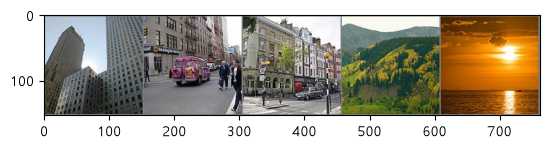

In [11]:
print([class_names[labels[i].item()] for i in range(5)])
out = make_grid(imgs[:5])
imshow(out)

In [12]:
class Model1(nn.Module):
    def __init__(self):
        super(Model1, self).__init__()
        self.linear = nn.Linear(150 * 150 * 3, 6)
        self.flatten = nn.Flatten()

    # Module의 상속받은 메서드
    # nn.Module은 생성자 실행 후 forward 메서드를 자동으로 한 번 거쳐 가공된 값이 반환됨.
    # forward의 레이어가 1개보다 늘어나면 딥러닝, 1개면 머신러닝
    def forward(self, x):
        x = self.flatten(x)
        x = self.linear(x)
        return x


In [13]:
class Model2(nn.Module):
    def __init__(self):
        super(Model2, self).__init__()
        self.linear1 = nn.Linear(150 * 150 * 3, 64)
        self.linear2 = nn.Linear(64, 6)
        self.flatten = nn.Flatten()

    # Module의 상속받은 메서드
    # nn.Module은 생성자 실행 후 forward 메서드를 자동으로 한 번 거쳐 가공된 값이 반환됨.
    # forward의 레이어가 1개보다 늘어나면 딥러닝, 1개면 머신러닝
    def forward(self, x):
        x = self.flatten(x)
        x = self.linear1(x)
        x = self.linear2(x)
        return x


In [14]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device("mps")
elif torch.xpu.is_available():
    device = torch.device("xpu")
else:
    device = torch.device("cpu")

print(f"현재 선택된 장치: {device}")

현재 선택된 장치: cpu


In [15]:
model1 = Model1().to(device)

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model1.parameters(), lr=0.001)

In [17]:
log_step = 10
epochs = 15

# 가장 좋았던 지점을 저장하기 위한 변수
best_val_acc = 0
best_epoch = 0

# epoch마다 history를 저장
history = []
accuracy = []

In [18]:
model1_path = os.path.join(base_path, r"weights/Model1")
model2_path = os.path.join(base_path, r"weights/Model2")
model3_path = os.path.join(base_path, r"weights/Model3")

In [19]:
os.makedirs(model1_path, exist_ok=True)
os.makedirs(model2_path, exist_ok=True)
os.makedirs(model3_path, exist_ok=True)

In [20]:
def train_one_epoch(model, dataloader, criterion, optimizer, device="cpu"):
    model.train()

    sum_losses = 0.0
    sum_accs = 0.0

    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # 학습
        optimizer.zero_grad()
        y_pred = model(X_batch) # 순전파
        loss = criterion(y_pred, y_batch)
        loss.backward() # 역전파
        optimizer.step() # 기울기 업데이트

        sum_losses += loss
        y_pred_index = y_pred.argmax(dim=1)
        acc = (y_batch == y_pred_index).float().mean().item() * 100
        sum_accs += acc

    avg_loss = sum_losses / len(dataloader)
    avg_acc = sum_accs / len(dataloader)
    return avg_loss, avg_acc

In [21]:
@torch.no_grad()
def evaluate(model, dataloader, criterion, device="cpu"):
    model.eval()
    sum_losses = 0.0
    sum_accs = 0.0

    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # 평가
        y_pred = model(X_batch) # 순전파
        loss = criterion(y_pred, y_batch)

        sum_losses += loss
        y_pred_index = y_pred.argmax(dim=1)
        acc = (y_batch == y_pred_index).float().mean().item() * 100
        sum_accs += acc

    avg_loss = sum_losses / len(dataloader)
    avg_acc = sum_accs / len(dataloader)
    return avg_loss, avg_acc

In [22]:
def train_model(model, model_name, train_loader, val_loader, criterion, optimizer, epochs, device, save_base_dir):
    save_dir = os.path.join(save_base_dir, model_name)
    os.makedirs(save_dir, exist_ok=True)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0

    # 학습 시작
    print(f"------------{model_name} 학습 시작 --------------")
    for epoch in range(epochs):
        lr = optimizer.param_groups[0]["lr"]

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        print(f"Epoch: {epoch + 1} | Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.2f}%")
        print(f"Epoch: {epoch + 1} | Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_acc:.2f}%")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), os.path.join(save_dir, "best_model.pth"))

    torch.save(model.state_dict(), os.path.join(save_dir, f"last_model_{epochs}.pth"))
    print(f"------------{model_name} 학습 완료 --------------")

    return history

In [23]:
criterion = nn.CrossEntropyLoss()

In [24]:
model1 = Model1().to(device)
optimizer1 = optim.Adam(model1.parameters(), lr=0.001)

history1 = train_model(
    model=model1, 
    model_name="Model1", 
    train_loader=train_dataloader, 
    val_loader=val_dataloader,
    criterion=criterion, 
    optimizer=optimizer1, 
    epochs=10, 
    device=device, 
    save_base_dir=os.path.join(base_path, "weights")
)

------------Model1 학습 시작 --------------


KeyboardInterrupt: 

## 모델 평가

In [ ]:
base_model_path = os.path.join(base_path, "weights", "Model1", "best_model.pth")

model1_test = Model1()
model1.load_state_dict(torch.load(base_model_path, weights_only=False))

In [ ]:
test_loss, test_acc = evaluate(model1, test_dataloader, criterion)

In [ ]:
print(f"최종 Test Model1 | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f} %")

In [25]:
class Model2(nn.Module):
    def __init__(self):
        super(Model2, self).__init__()
        self.linear1 = nn.Linear(150 * 150 * 3, 64)
        self.linear2 = nn.Linear(64, 6)
        self.flatten = nn.Flatten()

    # Module의 상속받은 메서드
    # nn.Module은 생성자 실행 후 forward 메서드를 자동으로 한 번 거쳐 가공된 값이 반환됨.
    # forward의 레이어가 1개보다 늘어나면 딥러닝, 1개면 머신러닝
    def forward(self, x):
        x = self.flatten(x)
        x = self.linear1(x)
        x = self.linear2(x)
        return x

In [26]:
model2 = Model2().to(device)
optimizer2 = optim.Adam(model2.parameters(), lr=0.001)

history2 = train_model(
    model=model2, 
    model_name="Model2", 
    train_loader=train_dataloader, 
    val_loader=val_dataloader,
    criterion=criterion, 
    optimizer=optimizer1, 
    epochs=10, 
    device=device, 
    save_base_dir=os.path.join(base_path, "weights")
)

------------Model2 학습 시작 --------------
Epoch: 1 | Train Loss: 1.8301 | Train Accuracy: 14.70%
Epoch: 1 | Validation Loss: 1.8262 | Validation Accuracy: 14.92%
Epoch: 2 | Train Loss: 1.8292 | Train Accuracy: 14.81%
Epoch: 2 | Validation Loss: 1.8248 | Validation Accuracy: 14.91%
Epoch: 3 | Train Loss: 1.8293 | Train Accuracy: 14.77%
Epoch: 3 | Validation Loss: 1.8244 | Validation Accuracy: 14.70%
Epoch: 4 | Train Loss: 1.8288 | Train Accuracy: 14.89%
Epoch: 4 | Validation Loss: 1.8276 | Validation Accuracy: 14.48%
Epoch: 5 | Train Loss: 1.8285 | Train Accuracy: 14.77%
Epoch: 5 | Validation Loss: 1.8257 | Validation Accuracy: 14.49%
Epoch: 6 | Train Loss: 1.8307 | Train Accuracy: 14.53%
Epoch: 6 | Validation Loss: 1.8261 | Validation Accuracy: 14.26%
Epoch: 7 | Train Loss: 1.8287 | Train Accuracy: 14.84%
Epoch: 7 | Validation Loss: 1.8283 | Validation Accuracy: 13.95%
Epoch: 8 | Train Loss: 1.8290 | Train Accuracy: 14.62%
Epoch: 8 | Validation Loss: 1.8268 | Validation Accuracy: 14.66%


In [27]:
base_model_path = os.path.join(base_path, "weights", "Model2", "best_model.pth")

model2_test = Model2()
model2.load_state_dict(torch.load(base_model_path, weights_only=False))

<All keys matched successfully>

In [28]:
test_loss, test_acc = evaluate(model2, test_dataloader, criterion)

In [29]:
print(f"최종 Test Model2 | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f} %")

최종 Test Model2 | Test Loss: 1.8298 | Test Accuracy: 13.35 %


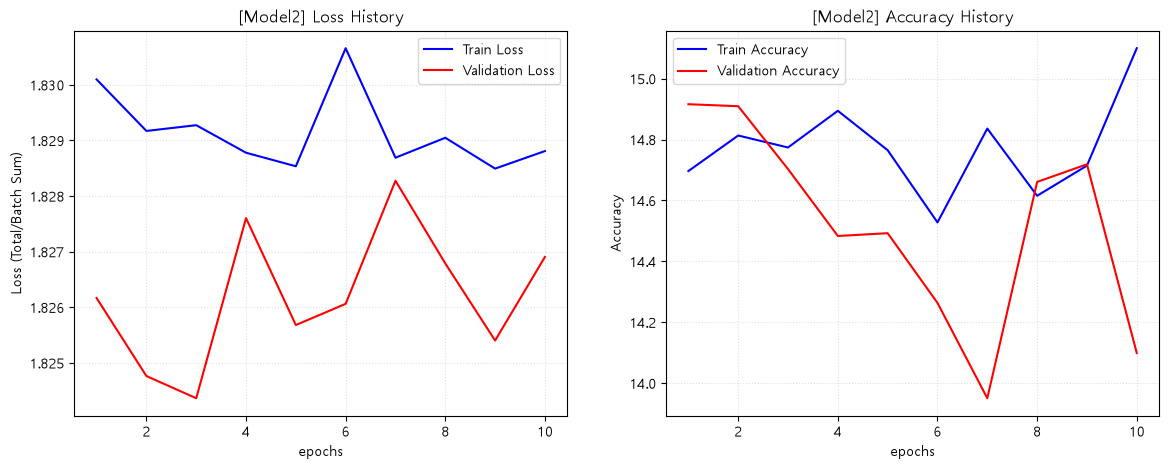

In [30]:
def plot_history(history, model_name):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    extract_vals = lambda lst: [x.detach().cpu().item() if isinstance(x, torch.Tensor) else float(x) for x in lst]
    
    axes[0].plot(epochs, extract_vals(history["train_loss"]), "blue", label="Train Loss")
    axes[0].plot(epochs, extract_vals(history["val_loss"]), "red", label="Validation Loss")
    axes[0].set_title(f"[{model_name}] Loss History")
    axes[0].set_xlabel("epochs")
    axes[0].set_ylabel("Loss (Total/Batch Sum)")
    axes[0].grid(True, linestyle=":", alpha=0.4)
    axes[0].legend()
    
    axes[1].plot(epochs, extract_vals(history["train_acc"]), "blue", label="Train Accuracy")
    axes[1].plot(epochs, extract_vals(history["val_acc"]), "red", label="Validation Accuracy")
    axes[1].set_title(f"[{model_name}] Accuracy History")
    axes[1].set_xlabel("epochs")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True, linestyle=":", alpha=0.4)
    axes[1].legend()

    plt.show()


plot_history(history2, "Model2")

In [34]:
class Model3(nn.Module):
    def __init__(self):
        super(Model3, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(150 * 150 * 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 6)
        )
        self.linear1 = nn.Linear(150 * 150 * 3, 128)
        self.linear2 = nn.Linear(128, 64)
        self.linear3 = nn.Linear(64, 32)
        self.linear4 = nn.Linear(32, 6)
        self.dropout1 = nn.Dropout(0.5)
        self.dropout2 = nn.Dropout(0.5)
        self.dropout3 = nn.Dropout(0.5)
        self.flatten = nn.Flatten()

    # Module의 상속받은 메서드
    def forward(self, x):
        return self.net(x)

In [35]:
model3 = Model3().to(device)
optimizer3 = optim.Adam(model3.parameters(), lr=0.001)

history3 = train_model(
    model=model3, 
    model_name="Model3", 
    train_loader=train_dataloader, 
    val_loader=val_dataloader,
    criterion=criterion, 
    optimizer=optimizer3, 
    epochs=10, 
    device=device, 
    save_base_dir=os.path.join(base_path, "weights")
)

------------Model3 학습 시작 --------------
Epoch: 1 | Train Loss: 1.9160 | Train Accuracy: 25.14%
Epoch: 1 | Validation Loss: 1.6048 | Validation Accuracy: 43.66%
Epoch: 2 | Train Loss: 1.6080 | Train Accuracy: 35.28%
Epoch: 2 | Validation Loss: 1.4896 | Validation Accuracy: 40.74%
Epoch: 3 | Train Loss: 1.5142 | Train Accuracy: 38.55%
Epoch: 3 | Validation Loss: 1.3543 | Validation Accuracy: 46.71%
Epoch: 4 | Train Loss: 1.4644 | Train Accuracy: 40.63%
Epoch: 4 | Validation Loss: 1.3151 | Validation Accuracy: 47.70%
Epoch: 5 | Train Loss: 1.4371 | Train Accuracy: 42.14%
Epoch: 5 | Validation Loss: 1.2888 | Validation Accuracy: 51.02%
Epoch: 6 | Train Loss: 1.4022 | Train Accuracy: 44.48%
Epoch: 6 | Validation Loss: 1.2707 | Validation Accuracy: 52.87%
Epoch: 7 | Train Loss: 1.3913 | Train Accuracy: 44.26%
Epoch: 7 | Validation Loss: 1.2720 | Validation Accuracy: 51.66%
Epoch: 8 | Train Loss: 1.3609 | Train Accuracy: 46.39%
Epoch: 8 | Validation Loss: 1.2568 | Validation Accuracy: 51.94%


In [37]:
base_model_path = os.path.join(base_path, "weights", "Model3", "best_model.pth")

model3_test = Model3()
model3.load_state_dict(torch.load(base_model_path, weights_only=False))

<All keys matched successfully>

In [38]:
test_loss, test_acc = evaluate(model3, test_dataloader, criterion)

In [39]:
print(f"최종 Test Model3 | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f} %")

최종 Test Model3 | Test Loss: 1.2702 | Test Accuracy: 51.88 %
